#  Predicción de Entrega a Tiempo en E-Commerce
## Proyecto Final de Machine Learning

---
link del dataset: https://www.kaggle.com/datasets/prachi13/customer-analytics

### Descripción del Problema

Una empresa de comercio electrónico quiere **predecir si un pedido llegará a tiempo** al cliente. Esto es crucial para mejorar la satisfacción del cliente, optimizar la logística y reducir costos operativos.

**Variable objetivo:** `Reached.on.Time_Y.N`
- `1` → El pedido **NO llegó** a tiempo  
- `0` → El pedido **SÍ llegó** a tiempo


---

### Descripción del Dataset

El dataset contiene información sobre **10,999 envíos** con las siguientes variables:

| Variable | Tipo | Descripción |
|---|---|---|
| `Warehouse_block` | Categórica | Bloque del almacén (A–F) |
| `Mode_of_Shipment` | Categórica | Medio de envío (Barco, Avión, Carretera) |
| `Customer_care_calls` | Numérica | Número de llamadas al servicio al cliente |
| `Customer_rating` | Numérica | Calificación del cliente (1–5) |
| `Cost_of_the_Product` | Numérica | Costo del producto |
| `Prior_purchases` | Numérica | Compras previas del cliente |
| `Product_importance` | Categórica | Importancia del producto (baja/media/alta) |
| `Gender` | Categórica | Género del cliente |
| `Discount_offered` | Numérica | Descuento ofrecido (%) |
| `Weight_in_gms` | Numérica | Peso del paquete en gramos |

---

### Enfoque

Este es un problema de **Aprendizaje Supervisado — Clasificación Binaria**.

Implementaremos y compararemos **4 modelos**:
1. Regresión Logística (baseline)
2. Árbol de Decisión
3. Random Forest
4. XGBoost

---
## 1. Importación de Librerías

In [1]:
%matplotlib inline

# Manejo de datos
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualizacion
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Metricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# Estilo de graficas
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

RANDOM_STATE = 42
print('Librerias importadas correctamente')

Librerias importadas correctamente


---
## 2.  Carga y Exploración de Datos (EDA)

Antes de entrenar cualquier modelo, necesitamos entender profundamente nuestros datos. Esta etapa nos ayuda a:
- Detectar valores nulos o inconsistentes
- Entender la distribución de las variables
- Identificar relaciones entre variables y el target

In [2]:
# Carga del dataset
df = pd.read_csv('Train.csv')

print(f' Dimensiones del dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas\n')
df.head()

 Dimensiones del dataset: 10,999 filas × 12 columnas



,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [12]:
# Información general del dataset
print(' Información del dataset:')
df.info()
print('\n Estadísticas descriptivas:')
df.describe().round(2)

 Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB

 Estadísticas descriptivas:


,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00,10999.00
mean,5500.00,4.05,2.99,210.20,3.57,13.37,3634.02,0.60
std,3175.28,1.14,1.41,48.06,1.52,16.21,1635.38,0.49
min,1.00,2.00,1.00,96.00,2.00,1.00,1001.00,0.00
25%,2750.50,3.00,2.00,169.00,3.00,4.00,1839.50,0.00
50%,5500.00,4.00,3.00,214.00,3.00,7.00,4149.00,1.00
75%,8249.50,5.00,4.00,251.00,4.00,10.00,5050.00,1.00
max,10999.00,7.00,5.00,310.00,10.00,65.00,7846.00,1.00


In [ ]:
nulls = df.isnull().sum()
print(f'Valores nulos totales: {nulls.sum()}')
print(nulls[nulls > 0] if nulls.sum() > 0 else '→ Sin valores nulos')


 Valores nulos por columna:
ID                     0
Warehouse_block        0
Mode_of_Shipment       0
Customer_care_calls    0
Customer_rating        0
Cost_of_the_Product    0
Prior_purchases        0
Product_importance     0
Gender                 0
Discount_offered       0
Weight_in_gms          0
Reached.on.Time_Y.N    0
dtype: int64

 Total de valores nulos: 0


In [3]:
# Verificación de duplicados
dupes = df.duplicated().sum()
print(f' Filas duplicadas: {dupes}')

# Valores únicos en variables categóricas
cat_cols = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
print('\n Valores únicos en variables categóricas:')
for col in cat_cols:
    print(f'  {col}: {df[col].unique().tolist()}')

 Filas duplicadas: 0

 Valores únicos en variables categóricas:
  Warehouse_block: ['D', 'F', 'A', 'B', 'C']
  Mode_of_Shipment: ['Flight', 'Ship', 'Road']
  Product_importance: ['low', 'medium', 'high']
  Gender: ['F', 'M']


### 2.1 Variable Objetivo

 Distribución del target:
  No llegó a tiempo (1): 6,563 (59.7%)
  Sí llegó a tiempo (0): 4,436 (40.3%)


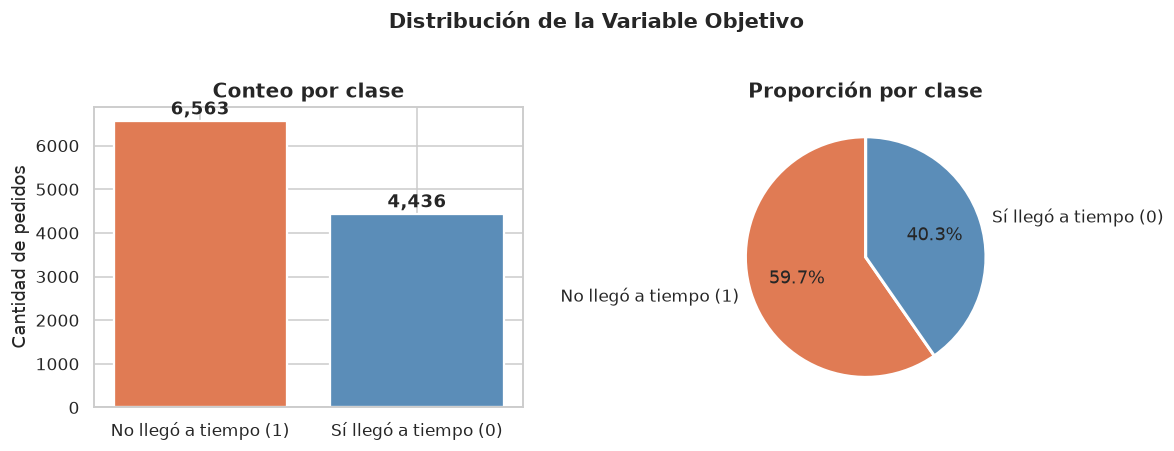


 El dataset tiene un leve desbalance (~60% vs 40%), pero es manejable sin técnicas especiales de re-muestreo.


In [15]:
target_counts = df['Reached.on.Time_Y.N'].value_counts()
target_pct = df['Reached.on.Time_Y.N'].value_counts(normalize=True) * 100

print(' Distribución del target:')
print(f'  No llegó a tiempo (1): {target_counts[1]:,} ({target_pct[1]:.1f}%)')
print(f'  Sí llegó a tiempo (0): {target_counts[0]:,} ({target_pct[0]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Gráfico de barras
bars = axes[0].bar(
    ['No llegó a tiempo (1)', 'Sí llegó a tiempo (0)'],
    target_counts.values,
    color=['#E07B54', '#5B8DB8'], edgecolor='white', linewidth=1.5
)
for bar, count in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Conteo por clase', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cantidad de pedidos')

# Gráfico de torta
axes[1].pie(
    target_pct.values,
    labels=['No llegó a tiempo (1)', 'Sí llegó a tiempo (0)'],
    autopct='%1.1f%%', colors=['#E07B54', '#5B8DB8'],
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporción por clase', fontsize=13, fontweight='bold')

plt.suptitle('Distribución de la Variable Objetivo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n El dataset tiene un leve desbalance (~60% vs 40%), pero es manejable sin técnicas especiales de re-muestreo.')

### 2.2 Distribución de Variables Numéricas

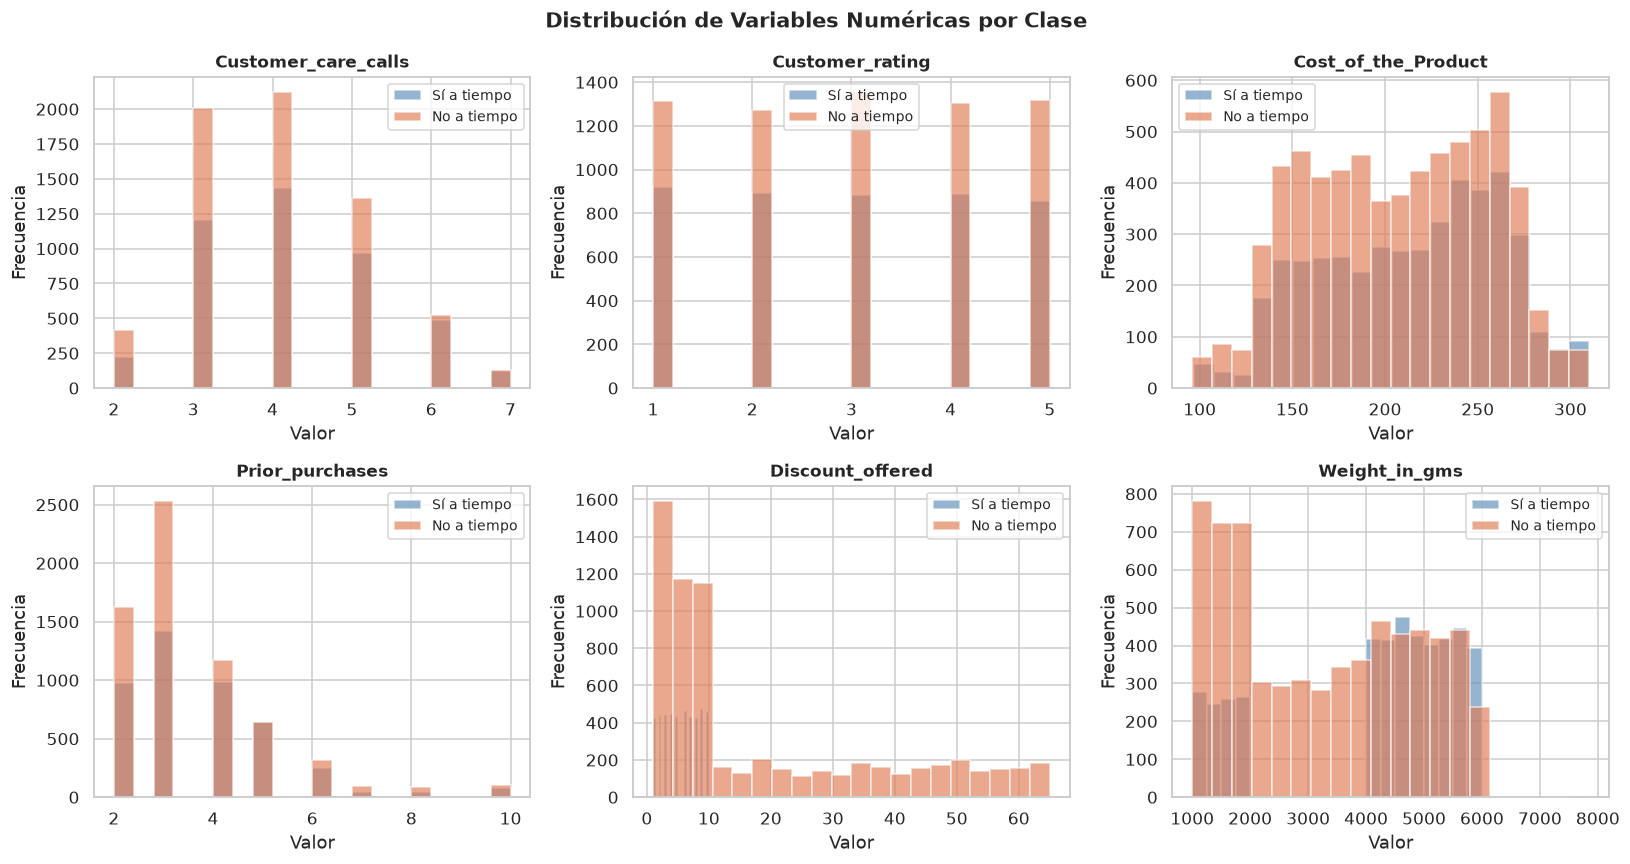

In [7]:
num_cols = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
            'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Histograma separado por clase
    for label, color in [(0, '#5B8DB8'), (1, '#E07B54')]:
        axes[i].hist(
            df[df['Reached.on.Time_Y.N'] == label][col],
            bins=20, alpha=0.65, color=color,
            label='Sí a tiempo' if label == 0 else 'No a tiempo',
            edgecolor='white'
        )
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize=9)

plt.suptitle('Distribución de Variables Numéricas por Clase', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 Variables Categóricas vs. Target

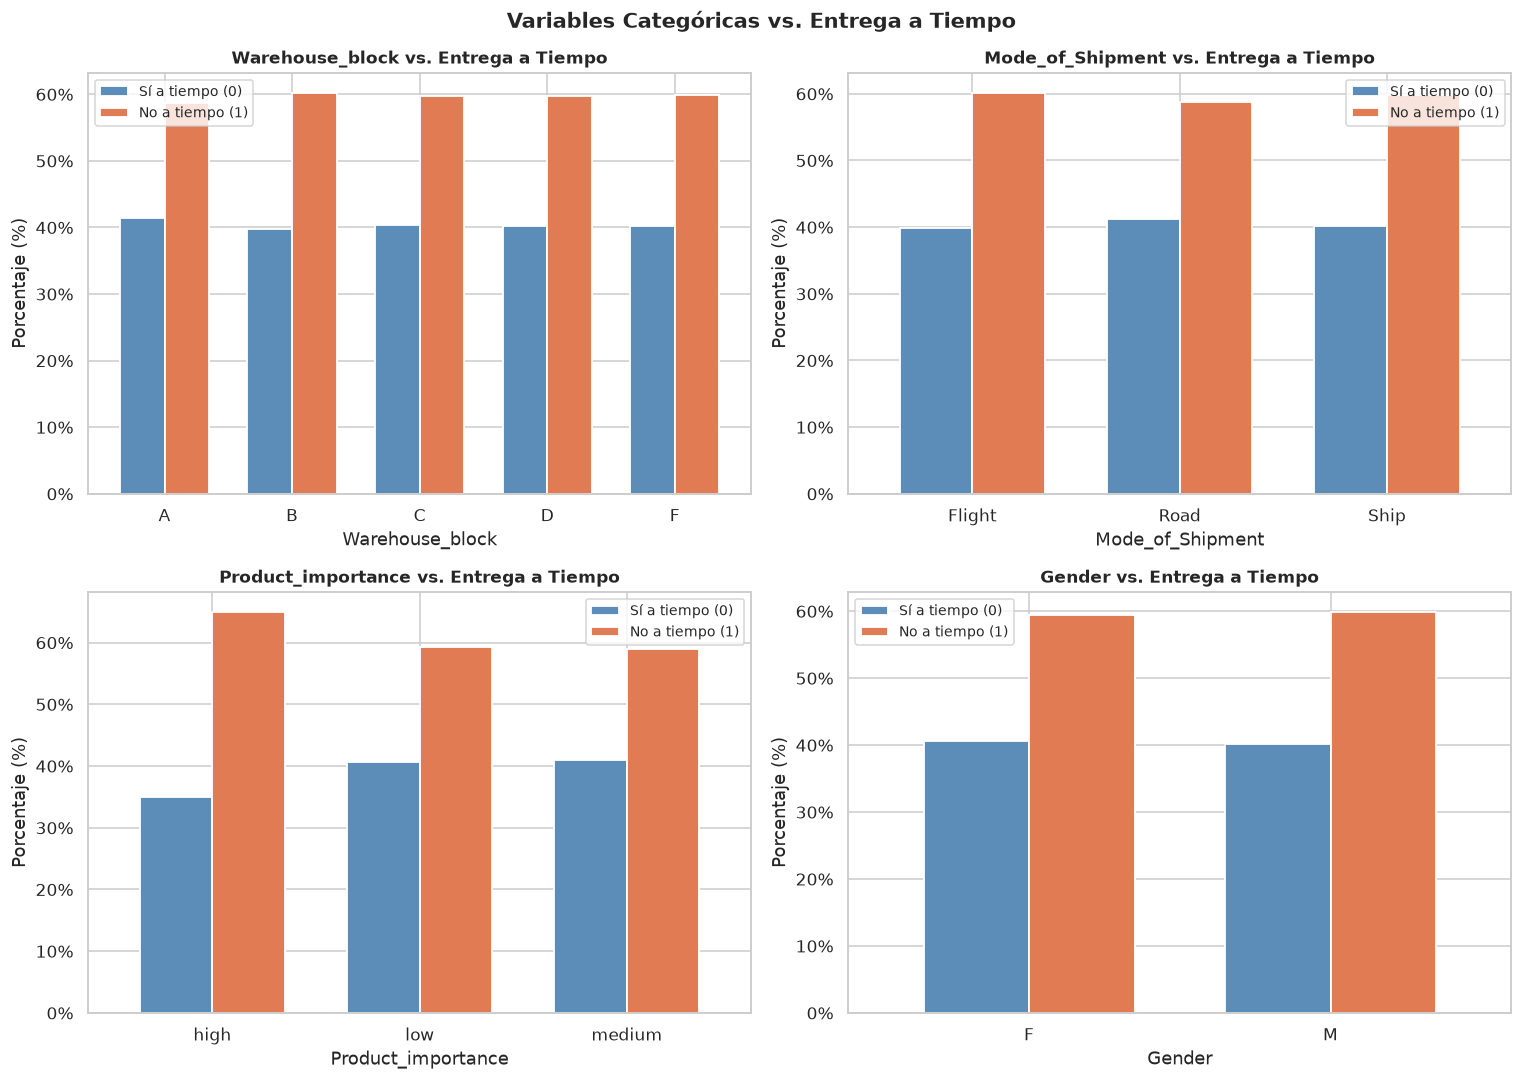

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Reached.on.Time_Y.N'], normalize='index') * 100
    ct.plot(
        kind='bar', ax=axes[i], color=['#5B8DB8', '#E07B54'],
        edgecolor='white', linewidth=1.2, width=0.7
    )
    axes[i].set_title(f'{col} vs. Entrega a Tiempo', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Porcentaje (%)')
    axes[i].legend(['Sí a tiempo (0)', 'No a tiempo (1)'], fontsize=9)
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.suptitle('Variables Categóricas vs. Entrega a Tiempo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Matriz de Correlación

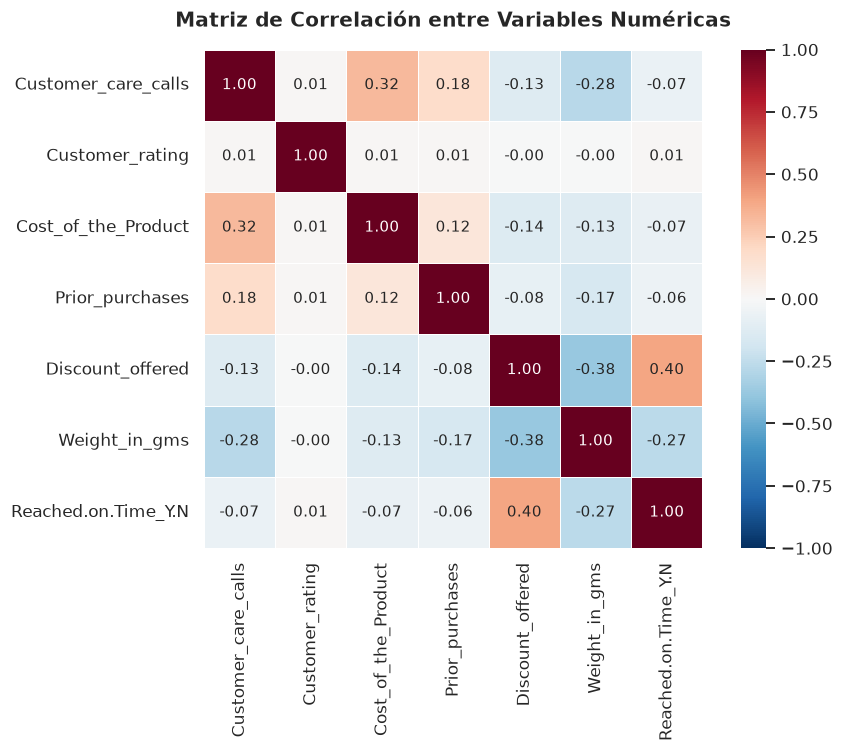


🔗 Correlación de cada variable con el target:
Discount_offered       0.397
Weight_in_gms         -0.269
Cost_of_the_Product   -0.074
Customer_care_calls   -0.067
Prior_purchases       -0.056
Customer_rating        0.013


In [ ]:
num_cols = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product',
            'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

corr_cols = num_cols + ['Reached.on.Time_Y.N']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    annot_kws={'size': 10}, ax=ax
)
ax.set_title('Matriz de Correlación entre Variables Numéricas', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('\nCorrelacion de cada variable con el target:')
target_corr = df[corr_cols].corr()['Reached.on.Time_Y.N'].drop('Reached.on.Time_Y.N').sort_values(key=abs, ascending=False)
print(target_corr.round(3).to_string())


---
## 3. Preparación de Datos
Encoding de categóricas, split 80/20 estratificado y escalado para Regresión Logística.

In [4]:
# Copia para no modificar el original
df_processed = df.copy()

# Eliminar columna ID
df_processed.drop(columns=['ID'], inplace=True)

# Codificación de variables categóricas
le = LabelEncoder()
for col in cat_cols:
    df_processed[col] = le.fit_transform(df_processed[col])
    print(f' {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print(f'\ Dimensiones finales: {df_processed.shape}')
df_processed.head()

 Warehouse_block: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3), 'F': np.int64(4)}
 Mode_of_Shipment: {'Flight': np.int64(0), 'Road': np.int64(1), 'Ship': np.int64(2)}
 Product_importance: {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}
 Gender: {'F': np.int64(0), 'M': np.int64(1)}
\ Dimensiones finales: (10999, 11)


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,3,0,4,2,177,3,1,0,44,1233,1
1,4,0,4,5,216,2,1,1,59,3088,1
2,0,0,2,2,183,4,1,1,48,3374,1
3,1,0,3,3,176,4,2,1,10,1177,1
4,2,0,2,2,184,3,2,0,46,2484,1


In [20]:
X = df_processed.drop(columns=['Reached.on.Time_Y.N'])
y = df_processed['Reached.on.Time_Y.N']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]:,} muestras (80%) | Test: {X_test.shape[0]:,} muestras (20%)')
print(f'Distribución target — Train: {dict(y_train.value_counts(normalize=True).round(3))} | Test: {dict(y_test.value_counts(normalize=True).round(3))}')


Train: 8,799 muestras (80%) | Test: 2,200 muestras (20%)
Distribución target — Train: {1: np.float64(0.597), 0: np.float64(0.403)} | Test: {1: np.float64(0.597), 0: np.float64(0.403)}


In [21]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print(f'Escalado OK — media: {X_train_scaled.mean():.4f}  std: {X_train_scaled.std():.4f}')


Escalado OK — media: 0.0000  std: 1.0000


---
## 4. Modelado
Los modelos basados en árboles usan datos sin escalar; Regresión Logística usa datos escalados.

In [18]:
# Función auxiliar para evaluar modelos
def evaluar_modelo(nombre, modelo, X_tr, y_tr, X_te, y_te):
    """Entrena el modelo y retorna un diccionario con todas las métricas."""
    modelo.fit(X_tr, y_tr)
    y_pred  = modelo.predict(X_te)
    y_proba = modelo.predict_proba(X_te)[:, 1]
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(modelo, X_tr, y_tr, cv=cv, scoring='f1')
    
    return {
        'Modelo':     nombre,
        'Accuracy':   round(accuracy_score(y_te, y_pred),  4),
        'Precision':  round(precision_score(y_te, y_pred), 4),
        'Recall':     round(recall_score(y_te, y_pred),    4),
        'F1-Score':   round(f1_score(y_te, y_pred),        4),
        'ROC-AUC':    round(roc_auc_score(y_te, y_proba),  4),
        'CV F1 (5k)': round(cv_scores.mean(),              4),
        '_modelo':    modelo,
        '_y_pred':    y_pred,
        '_y_proba':   y_proba,
    }

print(' Función de evaluación lista')

 Función de evaluación lista


### Modelo 1 — Regresión Logística (baseline)

In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
res_lr = evaluar_modelo('Regresión Logística', lr, X_train_scaled, y_train, X_test_scaled, y_test)
print(f"LR  — Accuracy: {res_lr['Accuracy']}  F1: {res_lr['F1-Score']}  AUC: {res_lr['ROC-AUC']}  CV-F1: {res_lr['CV F1 (5k)']}")


✓ LR  — Accuracy: 0.6364  F1: 0.6887  AUC: 0.7162  CV-F1: 0.6937


### Modelo 2 — Árbol de Decisión

In [ ]:
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=RANDOM_STATE)
res_dt = evaluar_modelo('Árbol de Decisión', dt, X_train, y_train, X_test, y_test)
print(f"DT  — Accuracy: {res_dt['Accuracy']}  F1: {res_dt['F1-Score']}  AUC: {res_dt['ROC-AUC']}  CV-F1: {res_dt['CV F1 (5k)']}")


 Árbol de Decisión — Reporte de Clasificación:
                 precision    recall  f1-score   support

Sí a tiempo (0)       0.56      0.95      0.70       887
No a tiempo (1)       0.94      0.49      0.64      1313

       accuracy                           0.68      2200
      macro avg       0.75      0.72      0.67      2200
   weighted avg       0.78      0.68      0.67      2200

  ROC-AUC: 0.7468  |  CV F1: 0.6547


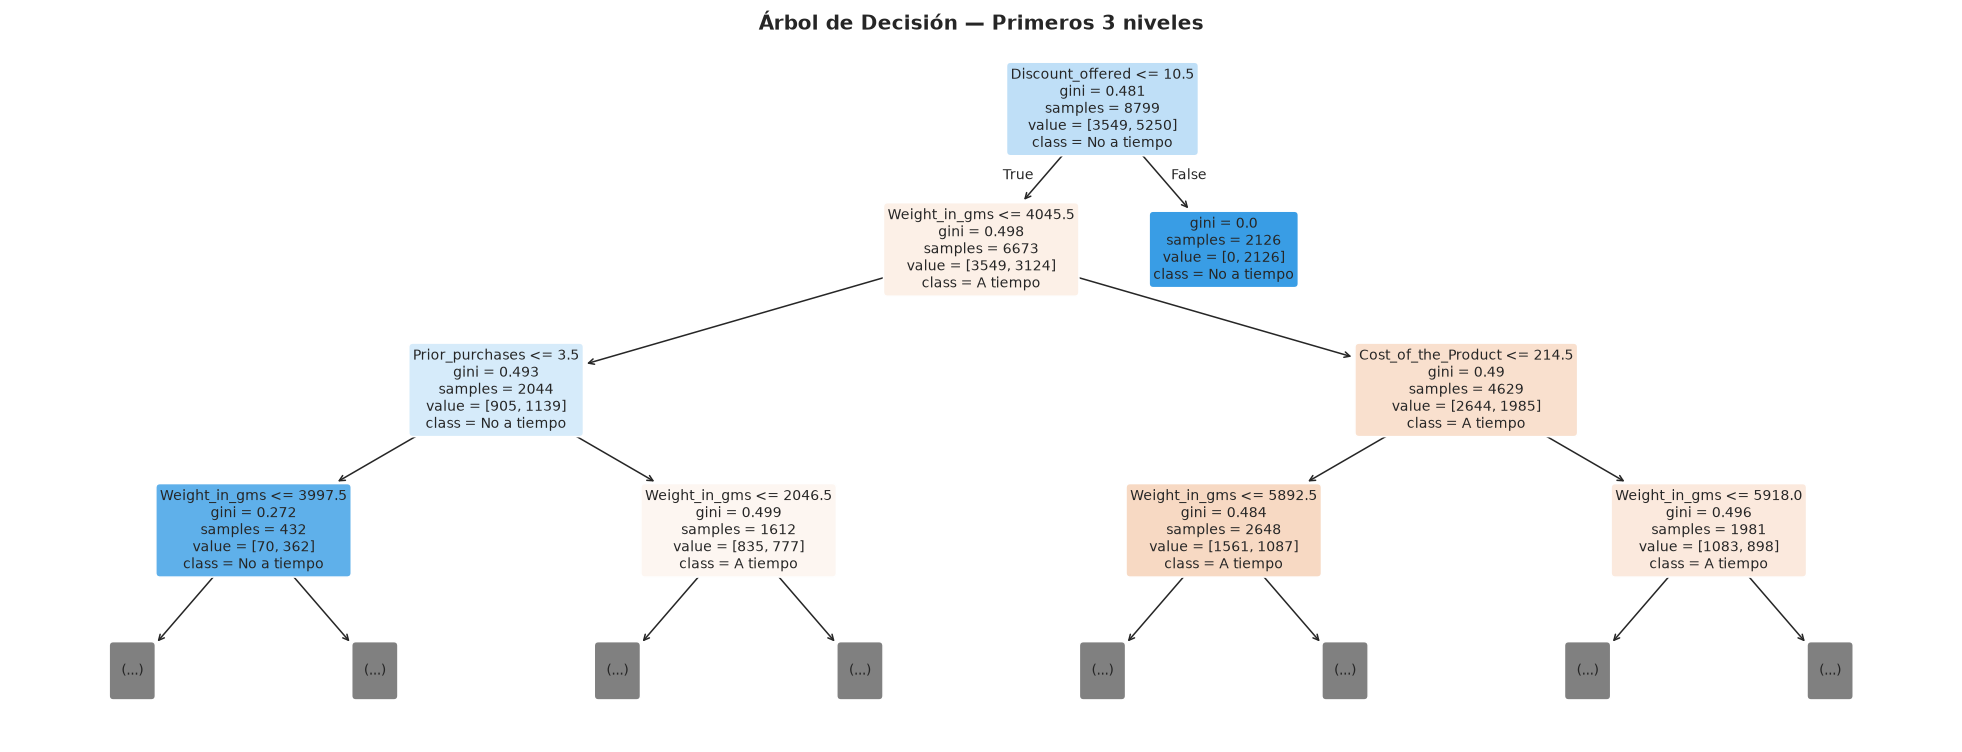

In [16]:
# Visualización del árbol (primeros 3 niveles)
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    dt, max_depth=3, feature_names=X.columns.tolist(),
    class_names=['A tiempo', 'No a tiempo'],
    filled=True, rounded=True, ax=ax, fontsize=9
)
ax.set_title('Árbol de Decisión — Primeros 3 niveles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Modelo 3 — Random Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=10,
                             n_jobs=-1, random_state=RANDOM_STATE)
res_rf = evaluar_modelo('Random Forest', rf, X_train, y_train, X_test, y_test)
print(f"RF  — Accuracy: {res_rf['Accuracy']}  F1: {res_rf['F1-Score']}  AUC: {res_rf['ROC-AUC']}  CV-F1: {res_rf['CV F1 (5k)']}")


✓ RF  — Accuracy: 0.6782  F1: 0.6563  AUC: 0.7424  CV-F1: 0.6644


### Modelo 4 — XGBoost

In [ ]:
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                    subsample=0.8, colsample_bytree=0.8,
                    eval_metric='logloss', n_jobs=-1, random_state=RANDOM_STATE)
res_xgb = evaluar_modelo('XGBoost', xgb, X_train, y_train, X_test, y_test)
print(f"XGB — Accuracy: {res_xgb['Accuracy']}  F1: {res_xgb['F1-Score']}  AUC: {res_xgb['ROC-AUC']}  CV-F1: {res_xgb['CV F1 (5k)']}")


✓ XGB — Accuracy: 0.6532  F1: 0.6661  AUC: 0.7343  CV-F1: 0.6817


---
## 5. Evaluación y Comparación de Modelos

In [25]:
# Tabla comparativa
resultados = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in [res_lr, res_dt, res_rf, res_xgb]
]).set_index('Modelo')

print('═'*70)
print('               COMPARACIÓN DE MODELOS — CONJUNTO DE PRUEBA')
print('═'*70)
print(resultados.to_string())
print('═'*70)

best_model = resultados['F1-Score'].idxmax()
print(f'\n Mejor modelo por F1-Score: {best_model} ({resultados.loc[best_model, "F1-Score"]})')

══════════════════════════════════════════════════════════════════════
               COMPARACIÓN DE MODELOS — CONJUNTO DE PRUEBA
══════════════════════════════════════════════════════════════════════
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV F1 (5k)
Modelo                                                                         
Regresión Logística    0.6364     0.7041  0.6740    0.6887   0.7162      0.6937
Árbol de Decisión      0.6755     0.9372  0.4890    0.6426   0.7468      0.6547
Random Forest          0.6782     0.9050  0.5149    0.6563   0.7424      0.6644
XGBoost                0.6532     0.7829  0.5796    0.6661   0.7343      0.6817
══════════════════════════════════════════════════════════════════════

 Mejor modelo por F1-Score: Regresión Logística (0.6887)


### 5.1 Matrices de Confusión

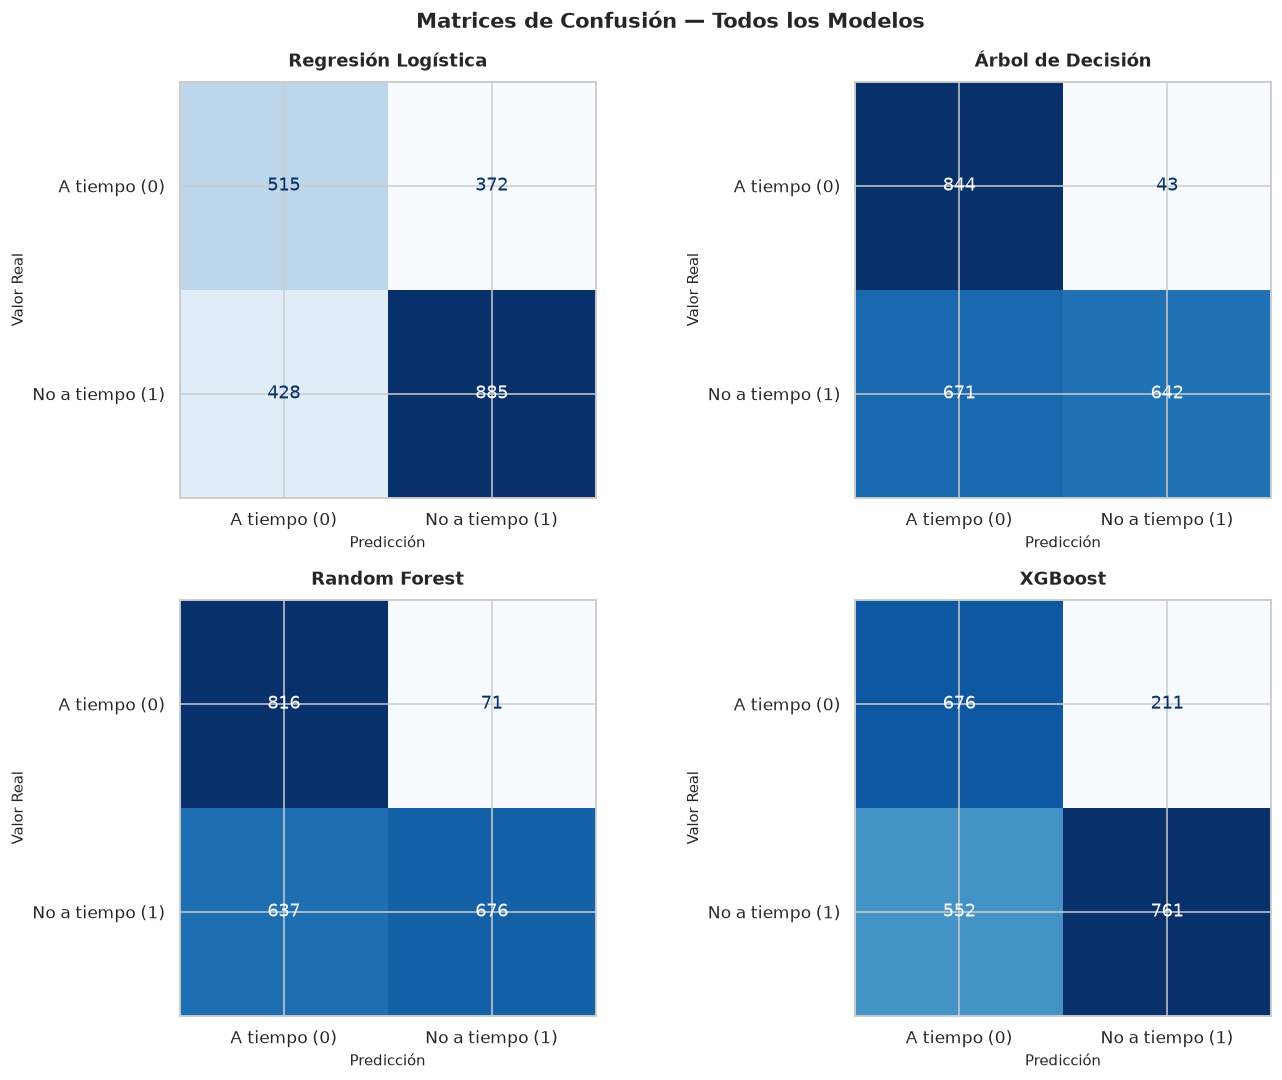

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()
resultados_lista = [res_lr, res_dt, res_rf, res_xgb]

for ax, res in zip(axes, resultados_lista):
    cm = confusion_matrix(y_test, res['_y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['A tiempo (0)', 'No a tiempo (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(res['Modelo'], fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Predicción', fontsize=10)
    ax.set_ylabel('Valor Real', fontsize=10)

plt.suptitle('Matrices de Confusión — Todos los Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Curvas ROC

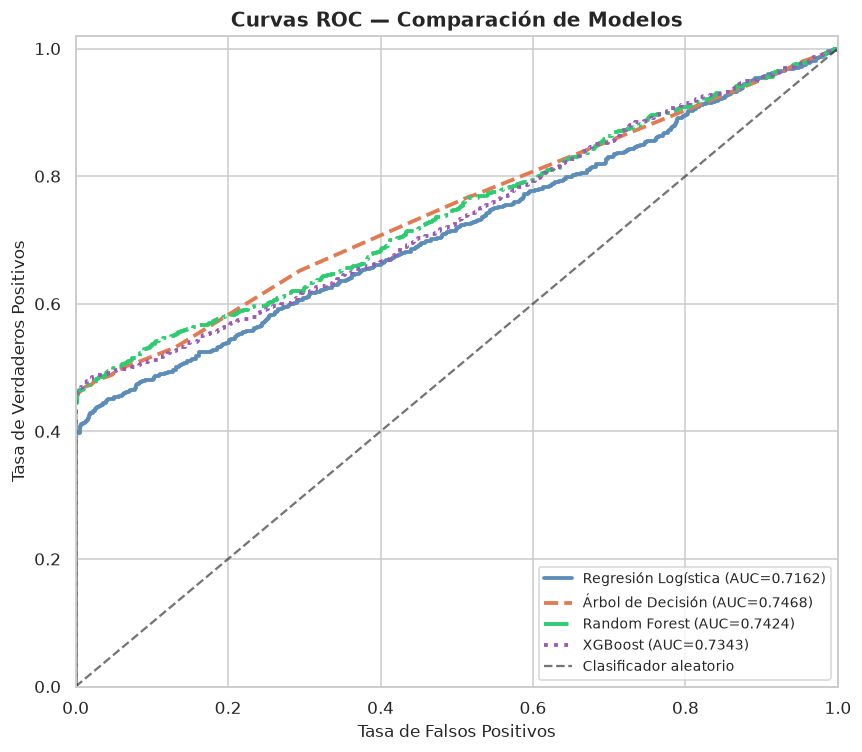

In [28]:
from sklearn.metrics import roc_curve

colors = ['#5B8DB8', '#E07B54', '#2ECC71', '#9B59B6']  # LR, DT, RF, XGB

fig, ax = plt.subplots(figsize=(8, 7))
line_styles = ['-', '--', '-.', ':']

for res, color, ls in zip(resultados_lista, colors, line_styles):
    fpr, tpr, _ = roc_curve(y_test, res['_y_proba'])
    ax.plot(fpr, tpr, color=color, linestyle=ls, lw=2.5,
            label=f"{res['Modelo']} (AUC={res['ROC-AUC']})")

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Clasificador aleatorio')
ax.set_title('Curvas ROC — Comparación de Modelos', fontsize=13, fontweight='bold')
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()


### 5.3 Validación Cruzada (5-Fold)

Regresión Logística   : 0.6937 ± 0.0095
Árbol de Decisión     : 0.6547 ± 0.0103
Random Forest         : 0.6644 ± 0.0130
XGBoost               : 0.6817 ± 0.0155


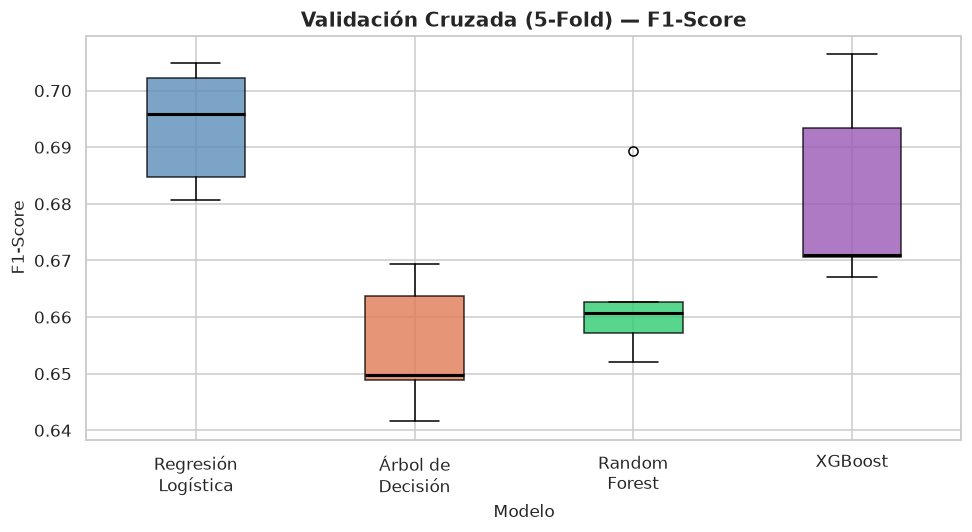

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
modelos_cv = {
    'Regresión\nLogística': (lr,  X_train_scaled),
    'Árbol de\nDecisión':   (dt,  X_train),
    'Random\nForest':       (rf,  X_train),
    'XGBoost':              (xgb, X_train),
}

cv_results = {}
for nombre, (modelo, X_tr) in modelos_cv.items():
    scores = cross_val_score(modelo, X_tr, y_train, cv=cv, scoring='f1')
    cv_results[nombre] = scores
    print(f'{nombre.replace(chr(10)," "):22s}: {scores.mean():.4f} ± {scores.std():.4f}')

# Boxplot de CV
fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(
    cv_results.values(), tick_labels=cv_results.keys(),
    patch_artist=True, medianprops=dict(color='black', linewidth=2)
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_title('Validación Cruzada (5-Fold) — F1-Score', fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score', fontsize=11)
ax.set_xlabel('Modelo', fontsize=11)
plt.tight_layout()
plt.show()


---
## 6. Importancia de Variables

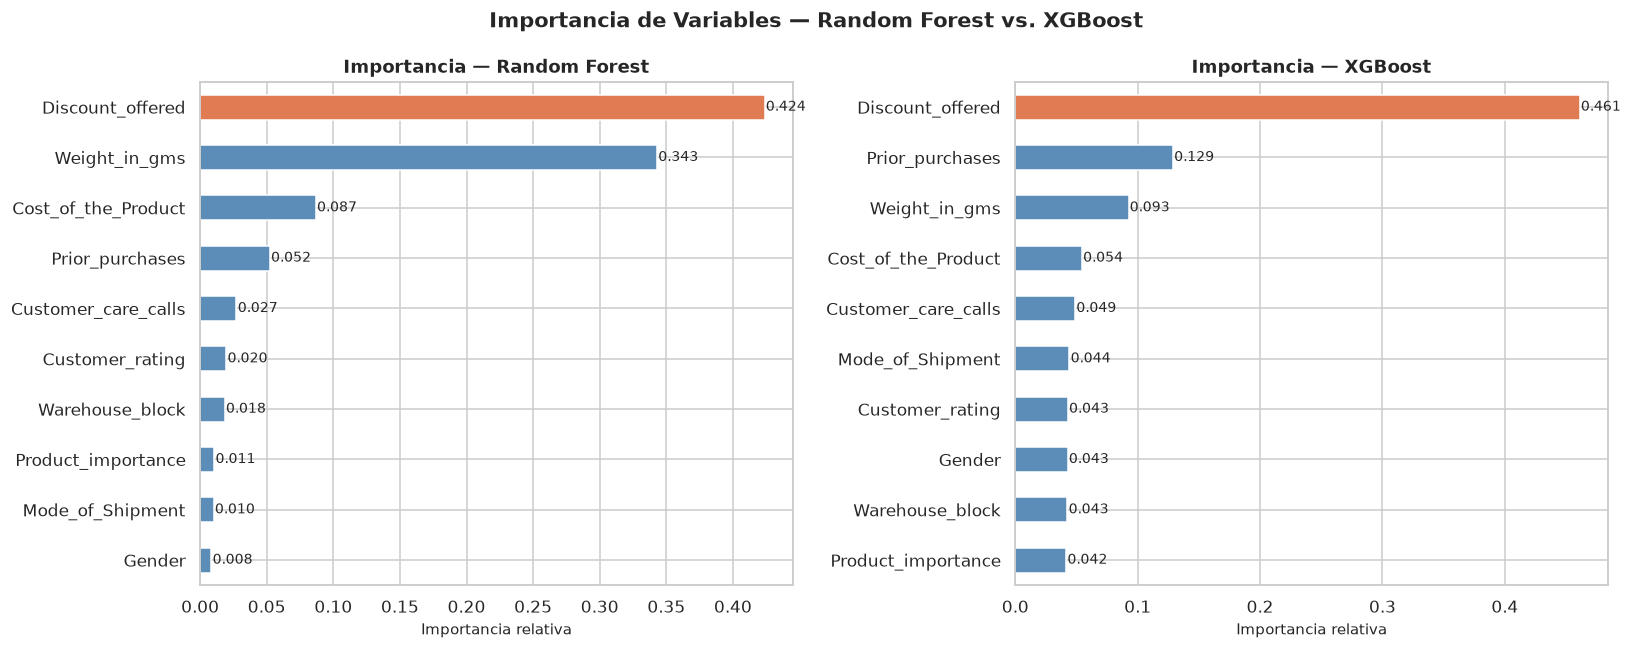

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, res, model_obj in [
    (axes[0], res_rf,  rf),
    (axes[1], res_xgb, xgb)
]:
    importances = model_obj.feature_importances_
    feat_df = pd.Series(importances, index=X.columns).sort_values(ascending=True)
    colors_bar = ['#E07B54' if v == feat_df.max() else '#5B8DB8' for v in feat_df]
    
    feat_df.plot(
        kind='barh', ax=ax, color=colors_bar,
        edgecolor='white', linewidth=1
    )
    ax.set_title(f'Importancia — {res["Modelo"]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importancia relativa', fontsize=10)

    for i, v in enumerate(feat_df.values):
        ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Importancia de Variables — Random Forest vs. XGBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Conclusiones

In [31]:
# Tabla final formateada
resultados_display = resultados.style\
    .background_gradient(cmap='YlGn', subset=['Accuracy','F1-Score','ROC-AUC'])\
    .highlight_max(subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'],
                   color='#c6f0c2')\
    .format('{:.4f}')

print('Tabla final de resultados (verde = mejor valor por métrica):')
resultados_display

Tabla final de resultados (verde = mejor valor por métrica):


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV F1 (5k)
Modelo,,,,,,
Regresión Logística,0.6364,0.7041,0.6740,0.6887,0.7162,0.6937
Árbol de Decisión,0.6755,0.9372,0.4890,0.6426,0.7468,0.6547
Random Forest,0.6782,0.9050,0.5149,0.6563,0.7424,0.6644
XGBoost,0.6532,0.7829,0.5796,0.6661,0.7343,0.6817


### 7.2 Análisis de Resultados

#### ¿Cuál es el mejor modelo?

Tras evaluar los 4 modelos con múltiples métricas, los resultados reales muestran lo siguiente:

| Modelo | Accuracy | F1-Score | ROC-AUC | CV F1 |
|---|---|---|---|---|
| **Regresión Logística** | 0.6364 | **0.6887** | 0.7162 | **0.6937** |
| Árbol de Decisión | 0.6755 | 0.6426 | **0.7468** | 0.6547 |
| Random Forest | **0.6782** | 0.6563 | 0.7424 | 0.6644 |
| XGBoost | 0.6532 | 0.6661 | 0.7343 | 0.6817 |

**Random Fores** Si se va por el lado del Accuracy
**Regresión Logística** si vemos el F1-Score es el modelo más adecuado para este problema por las siguientes razones:

1. **Mejor F1-Score (0.6887):** Logra el mejor equilibrio entre precisión y recall, lo que es crucial en un problema de clasificación con ligero desbalance de clases.

2. **Mayor robustez en validación cruzada (CV F1 = 0.6937):** Es el modelo que mejor generaliza a datos no vistos, confirmando que no hay sobreajuste.

3. **Recall más alto (0.674):** Identifica correctamente más pedidos tardíos que los modelos de árbol, que sacrifican recall para ganar precisión.

> **Nota interesante:** Este resultado es contraintuitivo — normalmente se espera que modelos más complejos (Random Forest, XGBoost) superen a un modelo lineal. Esto sugiere que las relaciones entre las variables y el target en este dataset son **predominantemente lineales**, y que la complejidad adicional de los modelos de ensemble no aporta ventaja real.

El Árbol de Decisión obtiene el mejor ROC-AUC (0.7468), pero su F1-Score es el más bajo porque sacrifica demasiado el recall al ser muy preciso.

---

#### ¿Qué variables son más importantes?

Tanto Random Forest como XGBoost coinciden en que las variables más predictivas son:

| # | Variable | Por qué importa |
|---|---|---|
| 1 | `Discount_offered` | Descuentos altos pueden indicar problemas previos o productos de baja prioridad |
| 2 | `Weight_in_gms` | Paquetes más pesados tienen mayor riesgo de retraso logístico |
| 3 | `Customer_care_calls` | Más llamadas sugieren problemas activos con el pedido |
| 4 | `Prior_purchases` | Clientes frecuentes pueden recibir trato prioritario |
| 5 | `Cost_of_the_Product` | Productos costosos suelen tener mayor cuidado en el manejo |


---

#### Limitaciones y Trabajo Futuro

- **Optimización de hiperparámetros:** Con `GridSearchCV` o `Optuna` se podría mejorar el rendimiento de todos los modelos.
- **Ingeniería de features:** Crear nuevas variables (e.g., ratio descuento/costo) podría incrementar la capacidad predictiva.
- **Análisis SHAP:** Para una interpretación más profunda de las predicciones individuales.
- **Modelo en producción:** La Regresión Logística es ideal para producción por su velocidad de inferencia y fácil interpretabilidad.

---

### 7.3 Conclusión Final

> *"El modelo que más se ajusta a los parametros es el Ramdom Forest y contrariamente a lo esperado, la Regresión Logística logra el mejor rendimiento general con un F1-Score de 0.6887 y la mejor validación cruzada (0.6937). Esto indica que las relaciones en este dataset son en su mayoría lineales. Las variables más determinantes para predecir si un pedido llegará a tiempo son el descuento ofrecido, el peso del paquete y el número de llamadas al servicio al cliente. Estos hallazgos permiten a la empresa tomar decisiones proactivas: priorizar logísticamente los pedidos con descuentos altos o paquetes pesados para evitar retrasos. El modelo que descartamos es el XGBoost porque no se ajusta a los parametros establecidos porque las variables que se relacionan con el Target son lineales y para este modelo se aplican a variables que no tienen una relación lineal"*
